In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from cssutils.css import selector
from nltk.corpus import stopwords

In [2]:
df = pd.read_csv(r'spam.csv', encoding='latin-1')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


## Preprocessing

In [3]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
df.duplicated().sum()

np.int64(403)

In [5]:
df.drop_duplicates(keep='first', inplace=True)

In [6]:
df.shape

(5169, 2)

In [7]:
df.rename(columns={'v1':'target', 'v2':'message'}, inplace=True)

In [8]:
df

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [9]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\garvc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [10]:
df['characters_length'] = df['message'].apply(lambda x: len(x))
df

,target,message,characters_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161
5568,ham,Will Ì_ b going to esplanade fr home?,37
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


In [11]:
df['words_length'] = df['message'].apply(lambda x: len(nltk.word_tokenize(x)))
df

,target,message,characters_length,words_length
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35
5568,ham,Will Ì_ b going to esplanade fr home?,37,9
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15
5570,ham,The guy did some bitching but I acted like i'd...,125,27


In [12]:
df['sentence_length'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))
df

,target,message,characters_length,words_length,sentence_length
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1


In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])

In [14]:
# 0 -> Not spam, 1 -> Spam
df

,target,message,characters_length,words_length,sentence_length
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


## EDA

In [16]:
px.defaults.template = 'plotly_dark'

In [17]:
ratio_df = df['target'].value_counts().reset_index()

In [18]:
ratio_df['target'] = ratio_df['target'].map({0 : 'Not Spam', 1 : 'Spam'})

In [19]:
ratio_df['percentage'] = round(ratio_df['count'] / ratio_df['count'].sum() * 100, 2)

In [20]:
ratio_df

,target,count,percentage
0,Not Spam,4516,87.37
1,Spam,653,12.63


In [21]:
px.bar(ratio_df, x='target', y='count', color='target', text='percentage')

In [22]:
df.groupby('target').describe().T

target                             0           1
characters_length count  4516.000000  653.000000
                  mean     70.459256  137.891271
                  std      56.358207   30.137753
                  min       2.000000   13.000000
                  25%      34.000000  132.000000
                  50%      52.000000  149.000000
                  75%      90.000000  157.000000
                  max     910.000000  224.000000
words_length      count  4516.000000  653.000000
                  mean     17.123782   27.667688
                  std      13.493970    7.008418
                  min       1.000000    2.000000
                  25%       8.000000   25.000000
                  50%      13.000000   29.000000
                  75%      22.000000   32.000000
                  max     220.000000   46.000000
sentence_length   count  4516.000000  653.000000
                  mean      1.820195    2.970904
                  std       1.383657    1.488425
                  min       1.000000    1.000000
                  25%       1.000000    2.000000
                  50%       1.000000    3.000000
                  75%       2.000000    4.000000
                  max      38.000000    9.000000

In [23]:
px.histogram(df,x='characters_length', color='target', barmode='overlay', opacity=0.7)

In [24]:
px.histogram(df,x='words_length', color='target', barmode='overlay', opacity=0.7)

<Axes: >

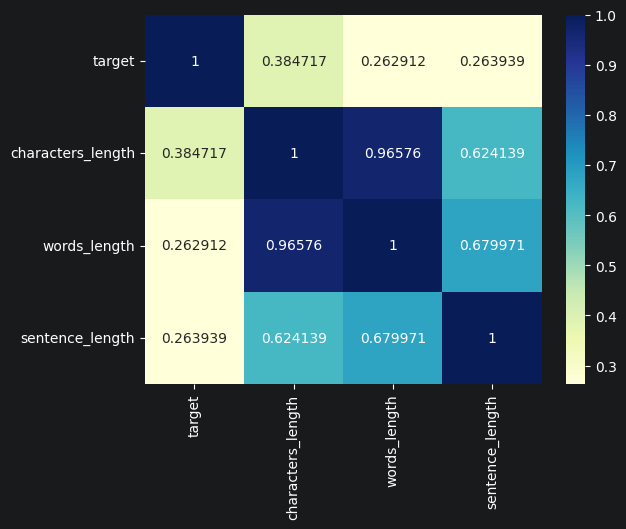

In [25]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='g', cmap='YlGnBu')

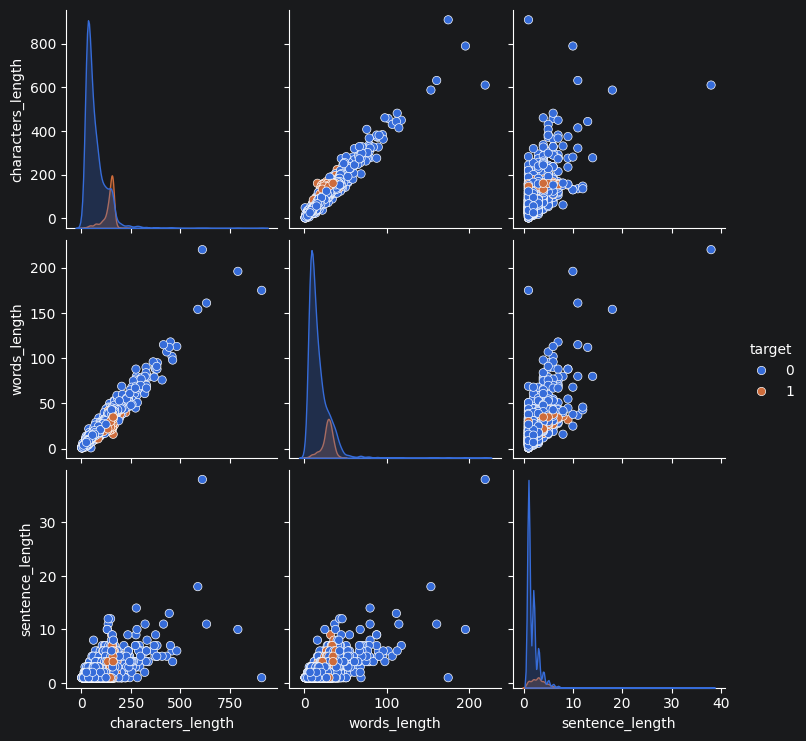

In [26]:
sns.pairplot(df, hue='target')

## Data/Text Preprocessing

In [15]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [16]:
from nltk.corpus import stopwords

In [17]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\garvc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
from nltk.stem.porter import PorterStemmer

In [19]:
def preprocess(text):
    text = text.lower()

    text = nltk.word_tokenize(text)
    text = [word for word in text if word.isalpha()]
    text = [word for word in text if not word in string.punctuation]
    text = [word for word in text if not word in stopwords.words('english')]

    ps = PorterStemmer()
    text = [ps.stem(word) for word in text]

    return ' '.join(text)

In [20]:
preprocess('Hi! How are you my darling??')

'hi darl'

In [21]:
transformed_text = df['message'].apply(preprocess)
df.insert(1, 'transformed_text', transformed_text)

In [22]:
df

,target,transformed_text,message,characters_length,words_length,sentence_length
0,0,go jurong point crazi avail bugi n great world...,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,ok lar joke wif u oni,Ok lar... Joking wif u oni...,29,8,2
2,1,free entri wkli comp win fa cup final tkt may ...,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,u dun say earli hor u c alreadi say,U dun say so early hor... U c already then say...,49,13,1
4,0,nah think goe usf live around though,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...,...
5567,1,time tri contact u pound prize claim easi call...,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,b go esplanad fr home,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,piti mood suggest,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,guy bitch act like interest buy someth els nex...,The guy did some bitching but I acted like i'd...,125,27,1


In [35]:
from wordcloud import WordCloud
wc = WordCloud(height=500, width=500, min_font_size=10, background_color='white')

In [36]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=' '))

In [37]:
px.imshow(spam_wc)

In [38]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=' '))
px.imshow(ham_wc)

In [39]:
all_words = []

for mssg in df[df['target'] == 1]['transformed_text'].to_list():
    for wrd in mssg.split():
        all_words.append(wrd)

all_words

['free',
 'entri',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 'may',
 'text',
 'fa',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 'freemsg',
 'hey',
 'darl',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'valid',
 'hour',
 'mobil',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 'six',
 'chanc',
 'win',
 'cash',
 'pound',
 'txt',
 'send',
 'cost',
 'tsandc',
 'appli',
 'repli',
 'hl',
 'info',
 'urgent',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 'c',
 'lccltd',
 'pobox',
 'xxxmobilemovieclub',
 'use',
 'credit',
 'click',
 'wap',
 'link',
 'next',
 'txt',
 'messag',
 'click',
 'http',
 'england',
 'v',
 'macedonia',
 'do

In [40]:
from collections import Counter
spam_freq_wrds = pd.DataFrame(Counter(all_words).most_common(30)).rename(columns={0:'word', 1:'count'})

In [41]:
px.bar(spam_freq_wrds, x='word', y='count', color='word', text='count')

In [42]:
all_words = []

for mssg in df[df['target'] == 0]['transformed_text'].to_list():
    for wrd in mssg.split():
        all_words.append(wrd)

all_words

['go',
 'jurong',
 'point',
 'crazi',
 'avail',
 'bugi',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amor',
 'wat',
 'ok',
 'lar',
 'joke',
 'wif',
 'u',
 'oni',
 'u',
 'dun',
 'say',
 'earli',
 'hor',
 'u',
 'c',
 'alreadi',
 'say',
 'nah',
 'think',
 'goe',
 'usf',
 'live',
 'around',
 'though',
 'even',
 'brother',
 'like',
 'speak',
 'treat',
 'like',
 'aid',
 'patent',
 'per',
 'request',
 'mell',
 'oru',
 'minnaminungint',
 'nurungu',
 'vettam',
 'set',
 'callertun',
 'caller',
 'press',
 'copi',
 'friend',
 'callertun',
 'gon',
 'na',
 'home',
 'soon',
 'want',
 'talk',
 'stuff',
 'anymor',
 'tonight',
 'k',
 'cri',
 'enough',
 'today',
 'search',
 'right',
 'word',
 'thank',
 'breather',
 'promis',
 'wont',
 'take',
 'help',
 'grant',
 'fulfil',
 'promis',
 'wonder',
 'bless',
 'time',
 'date',
 'sunday',
 'oh',
 'k',
 'watch',
 'eh',
 'u',
 'rememb',
 'spell',
 'name',
 'ye',
 'v',
 'naughti',
 'make',
 'v',
 'wet',
 'fine',
 'thatåõ',
 'way',
 'u',
 '

In [43]:
ham_freq_wrds = pd.DataFrame(Counter(all_words).most_common(30)).rename(columns={0:'word', 1:'count'})

In [44]:
px.bar(ham_freq_wrds, x='word', y='count', color='word', text='count')

## Model Building

In [23]:
df

,target,transformed_text,message,characters_length,words_length,sentence_length
0,0,go jurong point crazi avail bugi n great world...,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,ok lar joke wif u oni,Ok lar... Joking wif u oni...,29,8,2
2,1,free entri wkli comp win fa cup final tkt may ...,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,u dun say earli hor u c alreadi say,U dun say so early hor... U c already then say...,49,13,1
4,0,nah think goe usf live around though,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...,...
5567,1,time tri contact u pound prize claim easi call...,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,b go esplanad fr home,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,piti mood suggest,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,guy bitch act like interest buy someth els nex...,The guy did some bitching but I acted like i'd...,125,27,1


### CountVectorizer

In [46]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [47]:
X = cv.fit_transform(df['transformed_text']).toarray()

In [48]:
X.shape

(5169, 5849)

In [24]:
y = df['target']

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report

In [52]:
y_train.value_counts()

target
0    3627
1     508
Name: count, dtype: int64

In [53]:
y_test.value_counts()

target
0    889
1    145
Name: count, dtype: int64

In [54]:
bnb = BernoulliNB(class_prior=[0.95,0.05])
bnb.fit(X_train, y_train)
y_pred = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9642166344294004
0.9655172413793104
[[885   4]
 [ 33 112]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       0.97      0.77      0.86       145

    accuracy                           0.96      1034
   macro avg       0.96      0.88      0.92      1034
weighted avg       0.96      0.96      0.96      1034



In [55]:
bnb.predict_proba(X_test)[:,1]

array([4.04052545e-06, 9.99996796e-01, 3.11833170e-09, ...,
       9.99999940e-01, 7.54238946e-10, 3.09851262e-09], shape=(1034,))

In [56]:
mnb = MultinomialNB(class_prior=[0.95,0.05])
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9758220502901354
0.9166666666666666
[[877  12]
 [ 13 132]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       889
           1       0.92      0.91      0.91       145

    accuracy                           0.98      1034
   macro avg       0.95      0.95      0.95      1034
weighted avg       0.98      0.98      0.98      1034



### TFIDF

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [58]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [59]:
X.shape

(5169, 5849)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
bnb = BernoulliNB(class_prior=[0.95,0.05])
bnb.fit(X_train, y_train)
y_pred = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9642166344294004
0.9655172413793104
[[885   4]
 [ 33 112]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       0.97      0.77      0.86       145

    accuracy                           0.96      1034
   macro avg       0.96      0.88      0.92      1034
weighted avg       0.96      0.96      0.96      1034



In [62]:
mnb = MultinomialNB(class_prior=[0.95,0.05])
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9352030947775629
1.0
[[889   0]
 [ 67  78]]
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       889
           1       1.00      0.54      0.70       145

    accuracy                           0.94      1034
   macro avg       0.96      0.77      0.83      1034
weighted avg       0.94      0.94      0.93      1034



In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [64]:
svc = SVC(kernel='rbf', gamma='auto')
knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
mnb = MultinomialNB(class_prior=[0.95,0.05])
dtc = DecisionTreeClassifier(max_depth=5, random_state=42)
lrc = LogisticRegression(solver='liblinear',  l1_ratio=0 ,random_state=42, n_jobs=-1)
abc = AdaBoostClassifier(n_estimators=100, random_state=42)
bc = BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1)
etc = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
gdbt = GradientBoostingClassifier(n_estimators=100, random_state=42)
xgbt = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [65]:
classifiers = {
    'SVM' : svc,
    'KNN' : knc,
    'RF' : rfc,
    'MultinomialNB' : mnb,
    'DecisionTreeClassifier' : dtc,
    'LogisticRegression' : lrc,
    'AdaBoostClassifier' : abc,
    'BaggingClassifier' : bc,
    'ExtraTreesClassifier' : etc,
    'GradientBoostingClassifier' : gdbt,
    'XGBClassifier' : xgbt,
}

In [66]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    ac_score = accuracy_score(y_test, y_pred)
    prc_score = precision_score(y_test, y_pred)
    print('Accuracy Score: ', ac_score)
    print('Precision Score: ', prc_score)

    return ac_score, prc_score

In [67]:
acc_scores = []
prec_scores = []
for name, clf in classifiers.items():
    print('Name :', name)
    ac_score, prc_score = train_classifier(clf, X_train, y_train, X_test, y_test)
    print()

    acc_scores.append(ac_score)
    prec_scores.append(prc_score)

Name : SVM


C:\Users\garvc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



Accuracy Score:  0.8597678916827853
Precision Score:  0.0

Name : KNN
Accuracy Score:  0.9216634429400387
Precision Score:  1.0

Name : RF
Accuracy Score:  0.9690522243713733
Precision Score:  1.0

Name : MultinomialNB
Accuracy Score:  0.9352030947775629
Precision Score:  1.0

Name : DecisionTreeClassifier
Accuracy Score:  0.9332688588007737
Precision Score:  0.8015873015873016

Name : LogisticRegression
Accuracy Score:  0.9506769825918762
Precision Score:  0.9433962264150944

Name : AdaBoostClassifier


C:\Users\garvc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.



Accuracy Score:  0.9197292069632496
Precision Score:  0.7924528301886793

Name : BaggingClassifier
Accuracy Score:  0.9622823984526112
Precision Score:  0.8732394366197183

Name : ExtraTreesClassifier
Accuracy Score:  0.9758220502901354
Precision Score:  1.0

Name : GradientBoostingClassifier
Accuracy Score:  0.9564796905222437
Precision Score:  0.9464285714285714

Name : XGBClassifier
Accuracy Score:  0.971953578336557
Precision Score:  0.9461538461538461



In [68]:
performance_df = pd.DataFrame({'models' : classifiers.keys(), 'accuracy' : acc_scores, 'precision' : prec_scores})

In [69]:
performance_df.sort_values(['precision', 'accuracy'], ascending=[False, False])

,models,accuracy,precision
8,ExtraTreesClassifier,0.975822,1.000000
2,RF,0.969052,1.000000
3,MultinomialNB,0.935203,1.000000
1,KNN,0.921663,1.000000
9,GradientBoostingClassifier,0.956480,0.946429
10,XGBClassifier,0.971954,0.946154
5,LogisticRegression,0.950677,0.943396
7,BaggingClassifier,0.962282,0.873239
4,DecisionTreeClassifier,0.933269,0.801587
6,AdaBoostClassifier,0.919729,0.792453


In [70]:
px.bar(performance_df, x='models', y=['accuracy', 'precision'], barmode='group', title='Accuracy vs Precision')

In [71]:
# Voting Classifier
from sklearn.ensemble import VotingClassifier

rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
mnb = MultinomialNB(class_prior=[0.95,0.05])
etc = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)

voting = VotingClassifier(estimators=[('nb', mnb), ('et', etc), ('rf', rfc)], voting='soft')

In [72]:
voting.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('nb', ...), ('et', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.","[0.95, 0.05]"
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100


In [73]:
y_pred = voting.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.9642166344294004
1.0
[[889   0]
 [ 37 108]]


In [74]:
# Applying Stacking
from sklearn.ensemble import StackingClassifier

clf = StackingClassifier(estimators=[('nb', mnb), ('et', etc), ('rf', rfc)],final_estimator=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), n_jobs=-1)

In [75]:
clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('nb', ...), ('et', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",RandomForestC...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.","

In [76]:
y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.97678916827853
0.9416058394160584
[[881   8]
 [ 16 129]]


### Limiting Max features in TFIDF

In [28]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

In [29]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
svc = SVC(kernel='rbf', gamma='auto')
knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
mnb = MultinomialNB(class_prior=[0.95,0.05])
dtc = DecisionTreeClassifier(max_depth=5, random_state=42)
lrc = LogisticRegression(solver='liblinear',  l1_ratio=0 ,random_state=42, n_jobs=-1)
abc = AdaBoostClassifier(n_estimators=100, random_state=42)
bc = BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1)
etc = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
gdbt = GradientBoostingClassifier(n_estimators=100, random_state=42)
xgbt = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [81]:
classifiers = {
    'SVM' : svc,
    'KNN' : knc,
    'RF' : rfc,
    'MultinomialNB' : mnb,
    'DecisionTreeClassifier' : dtc,
    'LogisticRegression' : lrc,
    'AdaBoostClassifier' : abc,
    'BaggingClassifier' : bc,
    'ExtraTreesClassifier' : etc,
    'GradientBoostingClassifier' : gdbt,
    'XGBClassifier' : xgbt,
}

In [33]:
from sklearn.metrics import recall_score

In [83]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    ac_score = accuracy_score(y_test, y_pred)
    prc_score = precision_score(y_test, y_pred)
    rec_score = recall_score(y_test, y_pred)
    print('Accuracy Score: ', ac_score)
    print('Precision Score: ', prc_score)
    print('Recall Score: ', rec_score)

    return ac_score, prc_score, rec_score

In [84]:
acc_scores = []
prec_scores = []
rec_scores = []
for name, clf in classifiers.items():
    print('Name :', name)
    ac_score, prc_score, rc_score = train_classifier(clf, X_train, y_train, X_test, y_test)
    print()

    acc_scores.append(ac_score)
    prec_scores.append(prc_score)
    rec_scores.append(rc_score)

Name : SVM


C:\Users\garvc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



Accuracy Score:  0.8597678916827853
Precision Score:  0.0
Recall Score:  0.0

Name : KNN
Accuracy Score:  0.9081237911025145
Precision Score:  1.0
Recall Score:  0.3448275862068966

Name : RF
Accuracy Score:  0.9748549323017408
Precision Score:  1.0
Recall Score:  0.8206896551724138

Name : MultinomialNB
Accuracy Score:  0.9661508704061895
Precision Score:  1.0
Recall Score:  0.7586206896551724

Name : DecisionTreeClassifier
Accuracy Score:  0.9342359767891683
Precision Score:  0.8235294117647058
Recall Score:  0.6758620689655173

Name : LogisticRegression
Accuracy Score:  0.9613152804642167
Precision Score:  0.972972972972973
Recall Score:  0.7448275862068966

Name : AdaBoostClassifier


C:\Users\garvc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.



Accuracy Score:  0.9216634429400387
Precision Score:  0.8404255319148937
Recall Score:  0.5448275862068965

Name : BaggingClassifier
Accuracy Score:  0.9622823984526112
Precision Score:  0.9076923076923077
Recall Score:  0.8137931034482758

Name : ExtraTreesClassifier
Accuracy Score:  0.9777562862669246
Precision Score:  0.9841269841269841
Recall Score:  0.8551724137931035

Name : GradientBoostingClassifier
Accuracy Score:  0.9593810444874274
Precision Score:  0.9557522123893806
Recall Score:  0.7448275862068966

Name : XGBClassifier
Accuracy Score:  0.965183752417795
Precision Score:  0.9097744360902256
Recall Score:  0.8344827586206897



In [85]:
performance_df['acc_after_limiting_feat'] = acc_scores
performance_df['prec_after_limiting_feat'] = prec_scores
performance_df['rec_after_limiting_feat'] = rec_scores

In [86]:
performance_df

,models,accuracy,precision,acc_after_limiting_feat,prec_after_limiting_feat,rec_after_limiting_feat
0,SVM,0.859768,0.000000,0.859768,0.000000,0.000000
1,KNN,0.921663,1.000000,0.908124,1.000000,0.344828
2,RF,0.969052,1.000000,0.974855,1.000000,0.820690
3,MultinomialNB,0.935203,1.000000,0.966151,1.000000,0.758621
4,DecisionTreeClassifier,0.933269,0.801587,0.934236,0.823529,0.675862
5,LogisticRegression,0.950677,0.943396,0.961315,0.972973,0.744828
6,AdaBoostClassifier,0.919729,0.792453,0.921663,0.840426,0.544828
7,BaggingClassifier,0.962282,0.873239,0.962282,0.907692,0.813793
8,ExtraTreesClassifier,0.975822,1.000000,0.977756,0.984127,0.855172
9,GradientBoostingClassifier,0.956480,0.946429,0.959381,0.955752,0.744828


### Now training with Engineered Feature

In [87]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

In [88]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [89]:
X = np.hstack([X, df['characters_length'].to_numpy().reshape(-1,1)])

In [90]:
X.shape

(5169, 3001)

In [91]:
from sklearn.preprocessing import MaxAbsScaler, MinMaxScaler

scaler = MaxAbsScaler()
X = scaler.fit_transform(X)

In [92]:
X[:,3000]

array([0.12197802, 0.03186813, 0.17032967, ..., 0.06263736, 0.13736264,
       0.02857143], shape=(5169,))

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
svc = SVC(kernel='rbf', gamma='auto')
knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
mnb = MultinomialNB(class_prior=[0.95,0.05])
dtc = DecisionTreeClassifier(max_depth=5, random_state=42)
lrc = LogisticRegression(solver='liblinear',  l1_ratio=0 ,random_state=42, n_jobs=-1)
abc = AdaBoostClassifier(n_estimators=100, random_state=42)
bc = BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1)
etc = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
gdbt = GradientBoostingClassifier(n_estimators=100, random_state=42)
xgbt = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, device='cuda')

In [95]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    ac_score = accuracy_score(y_test, y_pred)
    prc_score = precision_score(y_test, y_pred)
    rec_score = recall_score(y_test, y_pred)
    print('Accuracy Score: ', ac_score)
    print('Precision Score: ', prc_score)
    print('Recall Score: ', rec_score)

    return ac_score, prc_score, rec_score

In [96]:
acc_scores = []
prec_scores = []
rec_scores = []
for name, clf in classifiers.items():
    print('Name :', name)
    ac_score, prc_score, rc_score = train_classifier(clf, X_train, y_train, X_test, y_test)
    print()

    acc_scores.append(ac_score)
    prec_scores.append(prc_score)
    rec_scores.append(rc_score)

Name : SVM


C:\Users\garvc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



Accuracy Score:  0.8597678916827853
Precision Score:  0.0
Recall Score:  0.0

Name : KNN
Accuracy Score:  0.9235976789168279
Precision Score:  1.0
Recall Score:  0.45517241379310347

Name : RF
Accuracy Score:  0.9709864603481625
Precision Score:  0.9831932773109243
Recall Score:  0.8068965517241379

Name : MultinomialNB
Accuracy Score:  0.9787234042553191
Precision Score:  1.0
Recall Score:  0.8482758620689655

Name : DecisionTreeClassifier
Accuracy Score:  0.9294003868471954
Precision Score:  0.8103448275862069
Recall Score:  0.6482758620689655

Name : LogisticRegression
Accuracy Score:  0.9738878143133463
Precision Score:  1.0
Recall Score:  0.8137931034482758

Name : AdaBoostClassifier


C:\Users\garvc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.



Accuracy Score:  0.9448742746615088
Precision Score:  0.8859649122807017
Recall Score:  0.696551724137931

Name : BaggingClassifier
Accuracy Score:  0.9632495164410058
Precision Score:  0.8639455782312925
Recall Score:  0.8758620689655172

Name : ExtraTreesClassifier
Accuracy Score:  0.9787234042553191
Precision Score:  0.9767441860465116
Recall Score:  0.8689655172413793

Name : GradientBoostingClassifier
Accuracy Score:  0.9593810444874274
Precision Score:  0.9401709401709402
Recall Score:  0.7586206896551724

Name : XGBClassifier
Accuracy Score:  0.9690522243713733
Precision Score:  0.9312977099236641
Recall Score:  0.8413793103448276



In [97]:
performance_df['acc_after_engineered_feat'] = acc_scores
performance_df['prec_after_engineered_feat'] = prec_scores
performance_df['rec_after_engineered_feat'] = rec_scores

In [110]:
performance_df

,models,accuracy,precision,acc_after_limiting_feat,prec_after_limiting_feat,rec_after_limiting_feat,acc_after_engineered_feat,prec_after_engineered_feat,rec_after_engineered_feat
0,SVM,0.859768,0.000000,0.859768,0.000000,0.000000,0.859768,0.000000,0.000000
1,KNN,0.921663,1.000000,0.908124,1.000000,0.344828,0.923598,1.000000,0.455172
2,RF,0.969052,1.000000,0.974855,1.000000,0.820690,0.970986,0.983193,0.806897
3,MultinomialNB,0.935203,1.000000,0.966151,1.000000,0.758621,0.978723,1.000000,0.848276
4,DecisionTreeClassifier,0.933269,0.801587,0.934236,0.823529,0.675862,0.929400,0.810345,0.648276
5,LogisticRegression,0.950677,0.943396,0.961315,0.972973,0.744828,0.973888,1.000000,0.813793
6,AdaBoostClassifier,0.919729,0.792453,0.921663,0.840426,0.544828,0.944874,0.885965,0.696552
7,BaggingClassifier,0.962282,0.873239,0.962282,0.907692,0.813793,0.963250,0.863946,0.875862
8,ExtraTreesClassifier,0.975822,1.000000,0.977756,0.984127,0.855172,0.978723,0.976744,0.868966
9,GradientBoostingClassifier,0.956480,0.946429,0.959381,0.955752,0.744828,0.959381,0.940171,0.758621


### Hyperparameter Tuning

In [99]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

In [100]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
from sklearn.model_selection import cross_val_score

In [36]:
from sklearn.metrics import make_scorer, precision_score
precision = make_scorer(precision_score, average='weighted', zero_division=0)

In [109]:
import optuna

def objective(trial):
    params = {
        'n_estimators' : trial.suggest_categorical('n_estimators', [100, 300, 500]),
        'max_depth' : None,
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight' : {0 : 1, 1 : 5},
        'n_jobs' : -1,
        'random_state' : 42
    }

    model = ExtraTreesClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring=precision).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print(study.best_params)

[I 2026-04-01 22:18:38,504] A new study created in memory with name: no-name-ee979ea2-e364-4780-a319-823ff8f844d5
[I 2026-04-01 22:18:48,227] Trial 0 finished with value: 0.9812582238543023 and parameters: {'n_estimators': 500, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 0 with value: 0.9812582238543023.
[I 2026-04-01 22:19:10,548] Trial 1 finished with value: 0.9776897846320343 and parameters: {'n_estimators': 500, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 0 with value: 0.9812582238543023.
[I 2026-04-01 22:26:19,069] Trial 2 finished with value: 0.9617966651889143 and parameters: {'n_estimators': 300, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9812582238543023.
[I 2026-04-01 22:38:47,822] Trial 3 finished with value: 0.9494998883098112 and parameters: {'n_estimators': 500, 'mi

{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'gini'}


In [113]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [100, 300, 500]),
        'max_depth': trial.suggest_categorical('max_depth', [None, 3, 5, 10]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.01, 0.05, 0.1, 0.2]),
        'subsample': trial.suggest_categorical('sunsample', [0.8, 0.9, 1]),
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.8, 0.9, 1.0]),
        'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', [1, 5, 7]),
        'n_jobs' : -1,
        'random_state' : 42,
        'device': 'cuda'
    }

    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring=precision, n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print(study.best_params)
print(study.best_value)

[I 2026-04-01 23:26:10,069] A new study created in memory with name: no-name-b8bbe353-e31d-4730-a3f5-c5cc60fb3303
[I 2026-04-01 23:26:14,801] Trial 0 finished with value: 0.9615375650728963 and parameters: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'sunsample': 0.9, 'colsample_bytree': 0.9, 'scale_pos_weight': 7}. Best is trial 0 with value: 0.9615375650728963.
[I 2026-04-01 23:26:17,562] Trial 1 finished with value: 0.9362841915957495 and parameters: {'n_estimators': 100, 'max_depth': None, 'learning_rate': 0.01, 'sunsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1}. Best is trial 0 with value: 0.9615375650728963.
[I 2026-04-01 23:26:21,655] Trial 2 finished with value: 0.9623388820656258 and parameters: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'sunsample': 0.9, 'colsample_bytree': 1.0, 'scale_pos_weight': 1}. Best is trial 2 with value: 0.9623388820656258.
[I 2026-04-01 23:26:26,298] Trial 3 finished with value: 0.9614249710405071 and 

{'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.2, 'sunsample': 1, 'colsample_bytree': 0.9, 'scale_pos_weight': 7}
0.9681457131989338


In [115]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [100, 300, 500]),
        'max_depth': trial.suggest_categorical('max_depth', [None, 3, 5, 10]),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'class_weight' : {0 : 1, 1 : 5},
        'n_jobs' : -1,
        'random_state' : 42,
    }

    model = RandomForestClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring=precision, n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print(study.best_params)
print(study.best_value)

[I 2026-04-01 23:33:55,380] A new study created in memory with name: no-name-fda38e1c-9e07-49e6-a129-cdd56d43501e
[I 2026-04-01 23:34:20,327] Trial 0 finished with value: 0.9276276253488986 and parameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': None, 'criterion': 'log_loss'}. Best is trial 0 with value: 0.9276276253488986.
[I 2026-04-01 23:34:23,715] Trial 1 finished with value: 0.8108262495923916 and parameters: {'n_estimators': 500, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 0 with value: 0.9276276253488986.
[I 2026-04-01 23:34:26,680] Trial 2 finished with value: 0.8988075327319741 and parameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 0 with value: 0.9276276253488986.
[I 2026-04-01 23:34:29,136] Trial 3 finished with value: 0.925239349

{'n_estimators': 100, 'max_depth': None, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'gini'}
0.9705410503871229


### Best ExtreTreeClassifier

In [142]:
etc = ExtraTreesClassifier(n_estimators= 500, min_samples_split= 10, min_samples_leaf= 1, max_features= 'log2', criterion= 'gini', n_jobs= -1, random_state= 42, max_depth=None, class_weight={0: 1, 1: 5})

In [143]:
etc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

In [148]:
y_proba = etc.predict_proba(X_test)[:,1]

In [149]:
threshold = 0.58
y_pred_custom = (y_proba >= threshold).astype(int)

In [150]:
print(accuracy_score(y_pred, y_pred_custom))
print(precision_score(y_pred, y_pred_custom))
print(recall_score(y_pred, y_pred_custom))
print(classification_report(y_pred, y_pred_custom))

0.9970986460348162
1.0
0.9767441860465116
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       905
           1       1.00      0.98      0.99       129

    accuracy                           1.00      1034
   macro avg       1.00      0.99      0.99      1034
weighted avg       1.00      1.00      1.00      1034



In [122]:
y_proba = etc.predict_proba(X_test)[:,1]

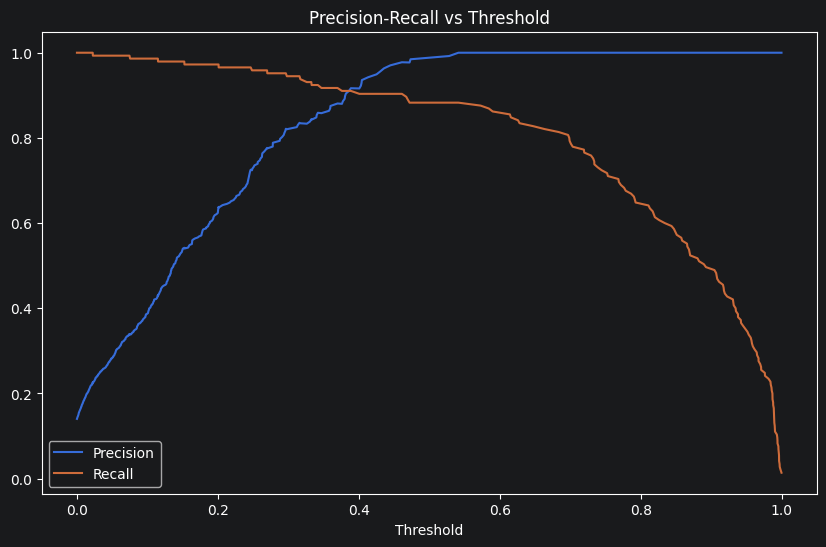

Precision: 1.0
Recall: 0.8689655172413793
Accuracy: 0.9816247582205029


In [132]:
# Try different thresholds
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

threshold = 0.58
y_pred_custom = (y_proba >= threshold).astype(int)
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("Accuracy:", accuracy_score(y_test, y_pred_custom))

### Feature Selection and Extraction

In [37]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k= 1000)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

In [207]:
etc = ExtraTreesClassifier(n_estimators= 500, min_samples_split= 6, min_samples_leaf= 1, max_features= 'log2', criterion= 'gini', n_jobs= -1, random_state= 42, max_depth=None, class_weight={0: 1, 1: 5})

In [208]:
etc.fit(X_train_sel, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [209]:
y_pred = etc.predict(X_test_sel)

In [210]:
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9806576402321083
0.9770992366412213
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       889
           1       0.98      0.88      0.93       145

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [211]:
y_proba = etc.predict_proba(X_test_sel)[:,1]

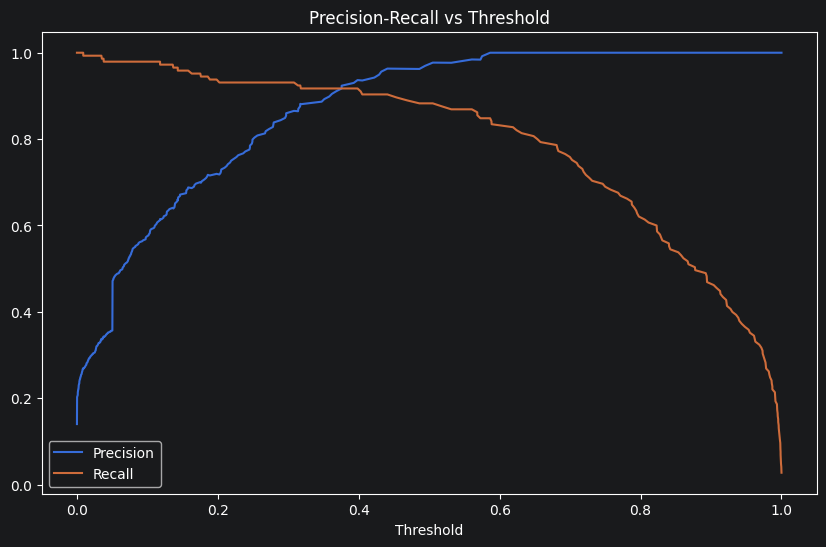

Precision: 1.0
Recall: 0.8482758620689655
Accuracy: 0.9787234042553191


In [212]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

threshold = 0.58
y_pred_custom = (y_proba >= threshold).astype(int)
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("Accuracy:", accuracy_score(y_test, y_pred_custom))

In [202]:
threshold = 0.61
y_pred_custom = (y_proba >= threshold).astype(int)

In [203]:
print(accuracy_score(y_pred, y_pred_custom))
print(precision_score(y_pred, y_pred_custom))
print(recall_score(y_pred, y_pred_custom))
print(classification_report(y_pred, y_pred_custom))

0.9912959381044487
1.0
0.9323308270676691
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       901
           1       1.00      0.93      0.96       133

    accuracy                           0.99      1034
   macro avg       1.00      0.97      0.98      1034
weighted avg       0.99      0.99      0.99      1034



In [205]:
def objective(trial):
    params = {
        'n_estimators' : trial.suggest_categorical('n_estimators', [100, 300, 500]),
        'max_depth' : trial.suggest_categorical('max_depth', [None, 3, 7, 10, 20]),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight' : {0 : 1, 1 : 5},
        'n_jobs' : -1,
        'random_state' : 42
    }

    model = ExtraTreesClassifier(**params)
    score = cross_val_score(model, X_train_sel, y_train, cv=3, scoring=precision).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print(study.best_params)

[I 2026-04-02 00:41:31,643] A new study created in memory with name: no-name-1ad3d344-29cc-4745-9ccf-bedc74fefe84
[I 2026-04-02 00:41:39,990] Trial 0 finished with value: 0.9418727080553243 and parameters: {'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9418727080553243.
[I 2026-04-02 00:41:43,128] Trial 1 finished with value: 0.9599343726182005 and parameters: {'n_estimators': 500, 'max_depth': None, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 1 with value: 0.9599343726182005.
[I 2026-04-02 00:41:45,064] Trial 2 finished with value: 0.9420705466416806 and parameters: {'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': None, 'criterion': 'entropy'}. Best is trial 1 with value: 0.9599343726182005.
[I 2026-04-02 00:41:48,177] Trial 3 finished with value: 0.937258

{'n_estimators': 500, 'max_depth': None, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'gini'}


In [206]:
def objective(trial):
    params = {
        'n_estimators' : 500,
        'max_depth' : None,
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': 'gini',
        'class_weight' : {0 : 1, 1 : 5},
        'n_jobs' : -1,
        'random_state' : 42
    }

    model = ExtraTreesClassifier(**params)
    score = cross_val_score(model, X_train_sel, y_train, cv=3, scoring=precision).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print(study.best_params)

[I 2026-04-02 00:45:09,997] A new study created in memory with name: no-name-b9f55db3-07ab-450b-9729-05384786b9a5
[I 2026-04-02 00:45:13,187] Trial 0 finished with value: 0.9606010022694963 and parameters: {'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.9606010022694963.
[I 2026-04-02 00:45:17,836] Trial 1 finished with value: 0.9692106119918694 and parameters: {'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9692106119918694.
[I 2026-04-02 00:46:07,216] Trial 2 finished with value: 0.9603553685081968 and parameters: {'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 1 with value: 0.9692106119918694.
[I 2026-04-02 00:46:12,394] Trial 3 finished with value: 0.9755023397112262 and parameters: {'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 3 with value: 0.9755023397112262.
[I 2026-04-02 00:46:15,306] Trial 4

{'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2'}


In [ ]:
# Most probably one of the final configuration
# etc = ExtraTreesClassifier(n_estimators= 500, min_samples_split= 6, min_samples_leaf= 1, max_features= 'log2', criterion= 'gini', n_jobs= -1, random_state= 42, max_depth=None, class_weight={0: 1, 1: 5})

In [260]:
selector = SelectKBest(chi2, k= 2000)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

In [261]:
rfc = RandomForestClassifier(n_estimators= 100, max_depth= None, min_samples_split= 8, min_samples_leaf= 2, max_features= 'sqrt', criterion= 'gini', n_jobs= -1, random_state= 42, class_weight={0: 1, 1: 5})

In [262]:
rfc.fit(X_train_sel, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [263]:
y_pred = rfc.predict(X_test_sel)

In [264]:
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9700193423597679
0.8851351351351351
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       889
           1       0.89      0.90      0.89       145

    accuracy                           0.97      1034
   macro avg       0.93      0.94      0.94      1034
weighted avg       0.97      0.97      0.97      1034



In [265]:
y_proba = rfc.predict_proba(X_test_sel)[:,1]

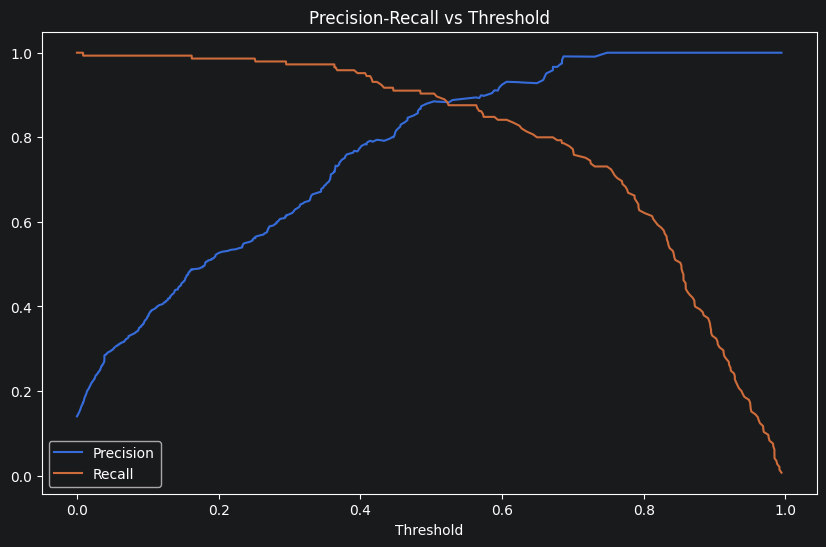

Precision: 1.0
Recall: 0.6413793103448275
Accuracy: 0.9497098646034816


In [266]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

threshold = 0.79
y_pred_custom = (y_proba >= threshold).astype(int)
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("Accuracy:", accuracy_score(y_test, y_pred_custom))

In [267]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [100, 300, 500]),
        'max_depth': trial.suggest_categorical('max_depth', [None, 3, 5, 10]),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'class_weight' : {0 : 1, 1 : 5},
        'n_jobs' : -1,
        'random_state' : 42,
    }

    model = RandomForestClassifier(**params)
    score = cross_val_score(model, X_train_sel, y_train, cv=3, scoring=precision, n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print(study.best_params)
print(study.best_value)

[I 2026-04-02 01:09:57,142] A new study created in memory with name: no-name-06f8975e-20de-4fb5-b165-d194f8f69aaa
[I 2026-04-02 01:10:00,320] Trial 0 finished with value: 0.9202084721800889 and parameters: {'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'log_loss'}. Best is trial 0 with value: 0.9202084721800889.
[I 2026-04-02 01:10:02,889] Trial 1 finished with value: 0.959893283256945 and parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'log_loss'}. Best is trial 1 with value: 0.959893283256945.
[I 2026-04-02 01:10:05,617] Trial 2 finished with value: 0.9599893449551896 and parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'log_loss'}. Best is trial 2 with value: 0.9599893449551896.
[I 2026-04-02 01:10:08,729] Trial 3 finished with value: 0.94

{'n_estimators': 300, 'max_depth': None, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}
0.9782614961612212


In [275]:
rfc = RandomForestClassifier(n_estimators= 300, max_depth= None, min_samples_split= 8, min_samples_leaf= 2, max_features= 'log2', criterion= 'gini', n_jobs= -1, random_state= 42, class_weight={0: 1, 1: 5})

In [276]:
rfc.fit(X_train_sel, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [277]:
y_pred = rfc.predict(X_test_sel)

In [278]:
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9738878143133463
0.9214285714285714
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       889
           1       0.92      0.89      0.91       145

    accuracy                           0.97      1034
   macro avg       0.95      0.94      0.95      1034
weighted avg       0.97      0.97      0.97      1034



In [279]:
y_proba = rfc.predict_proba(X_test_sel)[:,1]

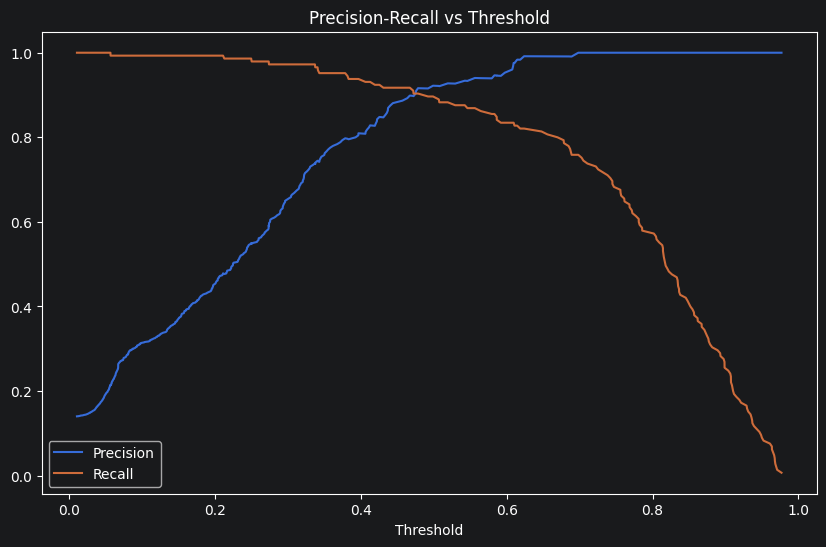

Precision: 1.0
Recall: 0.6551724137931034
Accuracy: 0.9516441005802708


In [281]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

threshold = 0.76
y_pred_custom = (y_proba >= threshold).astype(int)
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("Accuracy:", accuracy_score(y_test, y_pred_custom))

In [ ]:
# Almost final config for RandomForest
# rfc = RandomForestClassifier(n_estimators= 300, max_depth= None, min_samples_split= 8, min_samples_leaf= 2, max_features= 'log2', criterion= 'gini', n_jobs= -1, random_state= 42, class_weight={0: 1, 1: 5})

In [299]:
xgbt = XGBClassifier(n_estimators= 300, max_depth= 3, learning_rate= 0.2, subsample= 1, colsample_bytree= 1.0, scale_pos_weight= 5, n_jobs=-1, random_state= 42, device='cuda')

In [300]:
xgbt.fit(X_train_sel, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [301]:
y_pred = xgbt.predict(X_test_sel)

In [302]:
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9642166344294004
0.8648648648648649
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       889
           1       0.86      0.88      0.87       145

    accuracy                           0.96      1034
   macro avg       0.92      0.93      0.93      1034
weighted avg       0.96      0.96      0.96      1034



In [303]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [100, 300, 500]),
        'max_depth': trial.suggest_categorical('max_depth', [None, 3, 5, 10]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.01, 0.05, 0.1, 0.2]),
        'subsample': trial.suggest_categorical('subsample', [0.8, 0.9, 1]),
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.8, 0.9, 1.0]),
        'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', [1, 5, 7]),
        'n_jobs' : -1,
        'random_state' : 42,
        'device': 'cuda'
    }

    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train_sel, y_train, cv=3, scoring=precision, n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print(study.best_params)
print(study.best_value)

[I 2026-04-02 01:53:53,473] A new study created in memory with name: no-name-e54be08f-2eb9-4a15-a97d-c44824183f51
[I 2026-04-02 01:54:00,991] Trial 0 finished with value: 0.9406721173648274 and parameters: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.01, 'subsample': 1, 'colsample_bytree': 0.9, 'scale_pos_weight': 7}. Best is trial 0 with value: 0.9406721173648274.
[I 2026-04-02 01:54:05,262] Trial 1 finished with value: 0.9635261815261824 and parameters: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1}. Best is trial 1 with value: 0.9635261815261824.
[I 2026-04-02 01:54:09,195] Trial 2 finished with value: 0.9601668036114807 and parameters: {'n_estimators': 100, 'max_depth': None, 'learning_rate': 0.1, 'subsample': 1, 'colsample_bytree': 0.9, 'scale_pos_weight': 5}. Best is trial 1 with value: 0.9635261815261824.
[I 2026-04-02 01:54:19,393] Trial 3 finished with value: 0.9642315120808004 and para

{'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.2, 'subsample': 1, 'colsample_bytree': 0.9, 'scale_pos_weight': 7}
0.9670320676601957


In [310]:
y_proba = xgbt.predict_proba(X_test_sel)[:,1]

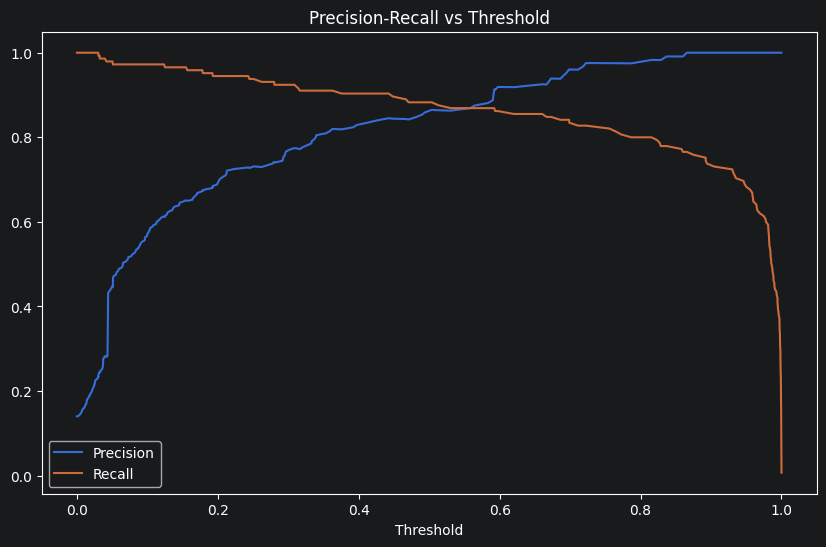

Precision: 0.9830508474576272
Recall: 0.8
Accuracy: 0.9700193423597679


In [312]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

threshold = 0.79
y_pred_custom = (y_proba >= threshold).astype(int)
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("Accuracy:", accuracy_score(y_test, y_pred_custom))

### Trying SVD

In [233]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=500, random_state=42)
X_train_svd = svd.fit_transform(X_train)

In [234]:
X_test_svd = svd.transform(X_test)

In [235]:
etc = ExtraTreesClassifier(n_estimators= 500, min_samples_split= 6, min_samples_leaf= 1, max_features= 'log2', criterion= 'gini', n_jobs= -1, random_state= 42, max_depth=None, class_weight={0: 1, 1: 5})

In [236]:
etc.fit(X_train_svd, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [237]:
y_pred = etc.predict(X_test_svd)

In [238]:
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9235976789168279
1.0
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       889
           1       1.00      0.46      0.63       145

    accuracy                           0.92      1034
   macro avg       0.96      0.73      0.79      1034
weighted avg       0.93      0.92      0.91      1034



In [239]:
y_proba = etc.predict_proba(X_test_svd)[:,1]

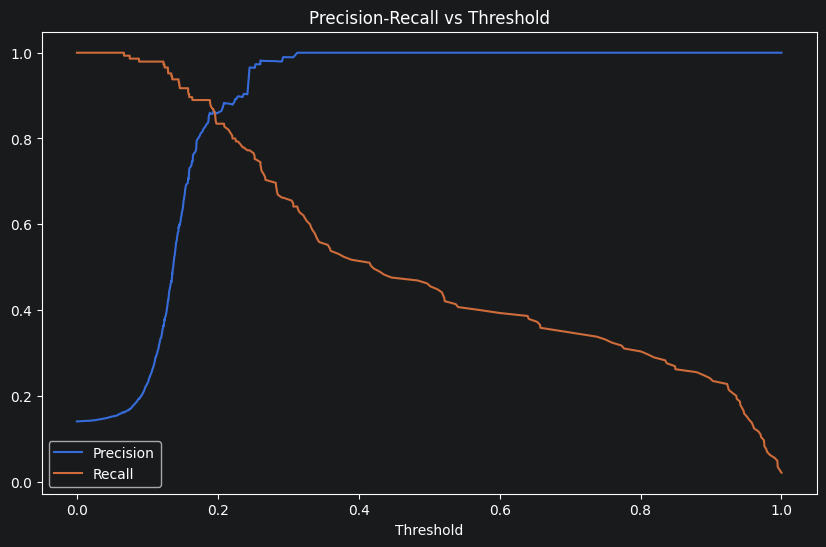

Precision: 1.0
Recall: 0.5103448275862069
Accuracy: 0.9313346228239845


In [240]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

threshold = 0.41
y_pred_custom = (y_proba >= threshold).astype(int)
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("Accuracy:", accuracy_score(y_test, y_pred_custom))

I am not further exploring SVD because it is giving too bad recall score and decent accuracy score, while other parameters are comparable with doing feature extraction

In [41]:
best_etc = ExtraTreesClassifier(n_estimators= 500, min_samples_split= 6, min_samples_leaf= 1, max_features= 'log2', criterion= 'gini', n_jobs= -1, random_state= 42, max_depth=None, class_weight={0: 1, 1: 5})
best_rtc = RandomForestClassifier(n_estimators= 300, max_depth= None, min_samples_split= 8, min_samples_leaf= 2, max_features= 'log2', criterion= 'gini', n_jobs= -1, random_state= 42, class_weight={0: 1, 1: 5})
best_xgbt = xgbt = XGBClassifier(n_estimators= 300, max_depth= 3, learning_rate= 0.2, subsample= 1, colsample_bytree= 1.0, scale_pos_weight= 5, n_jobs=-1, random_state= 42, device='cuda')

In [42]:
best_etc.fit(X_train_sel, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [43]:
best_rtc.fit(X_train_sel, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [44]:
best_xgbt.fit(X_train_sel, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [45]:
threshold = 0.79

In [48]:
voting = VotingClassifier([
    ('etc', best_etc),
    ('xgb', best_xgbt),
    ('rf', best_rtc),
    ],
    voting='soft',
    weights=[3, 1, 2],
    n_jobs=-1
)

In [49]:
voting.fit(X_train_sel, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('etc', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[3, 1, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [50]:
y_pred = voting.predict(X_test_sel)

c:\Users\garvc\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:751: UserWarning: [14:15:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [65]:
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9816247582205029
0.9772727272727273
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       889
           1       0.98      0.89      0.93       145

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [57]:
y_proba = voting.predict_proba(X_test_sel)[:,1]

In [58]:
y_pred_cust = (y_proba >= threshold).astype(int)

In [59]:
y_pred_cust

array([0, 0, 0, ..., 1, 0, 0], shape=(1034,))

In [54]:
from sklearn.metrics import accuracy_score, classification_report

In [60]:
print(accuracy_score(y_test, y_pred_cust))
print(precision_score(y_test, y_pred_cust))
print(classification_report(y_test, y_pred_cust))

0.9535783365570599
1.0
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       889
           1       1.00      0.67      0.80       145

    accuracy                           0.95      1034
   macro avg       0.97      0.83      0.89      1034
weighted avg       0.96      0.95      0.95      1034



In [63]:
clf = StackingClassifier(estimators=[
    ('etc', best_etc),
    ('xgb', best_xgbt),
    ('rf', best_rtc),
    ],
    final_estimator=ExtraTreesClassifier(n_estimators= 500, min_samples_split= 6, min_samples_leaf= 1, max_features= 'log2', criterion= 'gini', n_jobs= -1, random_state= 42, max_depth=None, class_weight={0: 1, 1: 5}),
    n_jobs=-1)

In [64]:
clf.fit(X_train_sel, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('etc', ...), ('xgb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",ExtraTreesCla...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number o

In [66]:
y_pred = clf.predict(X_test_sel)

In [73]:
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9729206963249516
0.8874172185430463
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       889
           1       0.89      0.92      0.91       145

    accuracy                           0.97      1034
   macro avg       0.94      0.95      0.94      1034
weighted avg       0.97      0.97      0.97      1034



In [70]:
y_proba = clf.predict_proba(X_test_sel)[:,1]

In [78]:
y_pred_cust = (y_proba >= 0.82).astype(int)

In [79]:
print(accuracy_score(y_test, y_pred_cust))
print(precision_score(y_test, y_pred_cust))
print(classification_report(y_test, y_pred_cust))

0.9825918762088974
0.9922480620155039
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       889
           1       0.99      0.88      0.93       145

    accuracy                           0.98      1034
   macro avg       0.99      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



### Doing Cross validation on best models to check whether they overfit or not

So till now, I think voting classifier with 1000 features is outperforming ExtraTreeClassifier with 3000 features by little margin

In [40]:
from sklearn.model_selection import cross_validate

etc = ExtraTreesClassifier(
    n_estimators=500, min_samples_split=10, min_samples_leaf=1,
    max_features='log2', criterion='gini', n_jobs=-1,
    random_state=42, max_depth=None, class_weight={0: 1, 1: 5}
)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_full = tfidf.fit_transform(df['transformed_text']).toarray()

scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}
cv_results = cross_validate(etc, X_full, y, cv=5, scoring=scoring, n_jobs=-1)

print("Accuracy:  ", cv_results['test_accuracy'].mean(), "±", cv_results['test_accuracy'].std())
print("Precision: ", cv_results['test_precision'].mean(), "±", cv_results['test_precision'].std())
print("Recall:    ", cv_results['test_recall'].mean(), "±", cv_results['test_recall'].std())
print("F1:        ", cv_results['test_f1'].mean(), "±", cv_results['test_f1'].std())

Accuracy:   0.9810401808033165 ± 0.0037042462310157777
Precision:  0.9845482295482295 ± 0.015678986930877138
Recall:     0.8637698179682912 ± 0.027268401536071466
F1:         0.919905013651726 ± 0.01626372088188326


In [80]:
voting = VotingClassifier([
    ('etc', best_etc),
    ('xgb', best_xgbt),
    ('rf', best_rtc),
    ],
    voting='soft',
    weights=[3, 1, 2],
    n_jobs=-1
)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_full = tfidf.fit_transform(df['transformed_text']).toarray()

scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}
cv_results = cross_validate(voting, X_full, y, cv=5, scoring=scoring, n_jobs=-1)

print("Accuracy:  ", cv_results['test_accuracy'].mean(), "±", cv_results['test_accuracy'].std())
print("Precision: ", cv_results['test_precision'].mean(), "±", cv_results['test_precision'].std())
print("Recall:    ", cv_results['test_recall'].mean(), "±", cv_results['test_recall'].std())
print("F1:        ", cv_results['test_f1'].mean(), "±", cv_results['test_f1'].std())

Accuracy:   0.9800730628149219 ± 0.004993687670884324
Precision:  0.9839842734535026 ± 0.010328457788548642
Recall:     0.8561127422196124 ± 0.03237467796653764
F1:         0.9153887406879386 ± 0.022063448271610032


In [81]:
voting = VotingClassifier([
    ('etc', best_etc),
    ('xgb', best_xgbt),
    ('rf', best_rtc),
    ],
    voting='soft',
    weights=[3, 1, 2],
    n_jobs=-1
)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_full = tfidf.fit_transform(df['transformed_text']).toarray()

scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}
cv_results = cross_validate(voting, X_train_sel, y_train, cv=5, scoring=scoring, n_jobs=-1)

print("Accuracy:  ", cv_results['test_accuracy'].mean(), "±", cv_results['test_accuracy'].std())
print("Precision: ", cv_results['test_precision'].mean(), "±", cv_results['test_precision'].std())
print("Recall:    ", cv_results['test_recall'].mean(), "±", cv_results['test_recall'].std())
print("F1:        ", cv_results['test_f1'].mean(), "±", cv_results['test_f1'].std())

Accuracy:   0.981378476420798 ± 0.0028202911220533452
Precision:  0.9846207618157127 ± 0.01449584495850827
Recall:     0.862162686856921 ± 0.02593085457643768
F1:         0.9189888701489382 ± 0.013578571766215427


In [82]:
clf = StackingClassifier(estimators=[
    ('etc', best_etc),
    ('xgb', best_xgbt),
    ('rf', best_rtc),
    ],
    final_estimator=ExtraTreesClassifier(n_estimators= 500, min_samples_split= 6, min_samples_leaf= 1, max_features= 'log2', criterion= 'gini', n_jobs= -1, random_state= 42, max_depth=None, class_weight={0: 1, 1: 5}),
    n_jobs=-1)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_full = tfidf.fit_transform(df['transformed_text']).toarray()

scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}
cv_results = cross_validate(clf, X_full, y, cv=5, scoring=scoring, n_jobs=-1)

print("Accuracy:  ", cv_results['test_accuracy'].mean(), "±", cv_results['test_accuracy'].std())
print("Precision: ", cv_results['test_precision'].mean(), "±", cv_results['test_precision'].std())
print("Recall:    ", cv_results['test_recall'].mean(), "±", cv_results['test_recall'].std())
print("F1:        ", cv_results['test_f1'].mean(), "±", cv_results['test_f1'].std())

Accuracy:   0.9794927920218852 ± 0.002480070380476166
Precision:  0.9223710654297452 ± 0.02544459972525002
Recall:     0.9158073987081622 ± 0.015925132983141497
F1:         0.9186819000680732 ± 0.008905311946605486


In [83]:
clf = StackingClassifier(estimators=[
    ('etc', best_etc),
    ('xgb', best_xgbt),
    ('rf', best_rtc),
    ],
    final_estimator=ExtraTreesClassifier(n_estimators= 500, min_samples_split= 6, min_samples_leaf= 1, max_features= 'log2', criterion= 'gini', n_jobs= -1, random_state= 42, max_depth=None, class_weight={0: 1, 1: 5}),
    n_jobs=-1)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_full = tfidf.fit_transform(df['transformed_text']).toarray()

scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}
cv_results = cross_validate(clf, X_train_sel, y_train, cv=5, scoring=scoring, n_jobs=-1)

print("Accuracy:  ", cv_results['test_accuracy'].mean(), "±", cv_results['test_accuracy'].std())
print("Precision: ", cv_results['test_precision'].mean(), "±", cv_results['test_precision'].std())
print("Recall:    ", cv_results['test_recall'].mean(), "±", cv_results['test_recall'].std())
print("F1:        ", cv_results['test_f1'].mean(), "±", cv_results['test_f1'].std())

Accuracy:   0.9782345828295043 ± 0.004118352204577138
Precision:  0.9121312379063793 ± 0.02574000436670496
Recall:     0.9113764317608231 ± 0.02718625972301106
F1:         0.9113182775172435 ± 0.016998624317955457


### Last Time trying with All Engineered features

In [101]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 3000))

In [102]:
X_engineered = np.hstack([X, df[['characters_length', 'words_length', 'sentence_length']]])
X_engineered

array([[  0.,   0.,   0., ..., 111.,  24.,   2.],
       [  0.,   0.,   0., ...,  29.,   8.,   2.],
       [  0.,   0.,   0., ..., 155.,  37.,   2.],
       ...,
       [  0.,   0.,   0., ...,  57.,  15.,   2.],
       [  0.,   0.,   0., ..., 125.,  27.,   1.],
       [  0.,   0.,   0., ...,  26.,   7.,   2.]], shape=(5169, 3003))

In [103]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_engineered, y, random_state=42, test_size=0.2)

In [104]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
X_train_1 = scaler.fit_transform(X_train_1)
X_test_1 = scaler.transform(X_test_1)

In [93]:
X_train_1[:,3001]

array([0.02272727, 0.02727273, 0.04090909, ..., 0.04545455, 0.10909091,
       0.11818182], shape=(4135,))

In [94]:
etc = ExtraTreesClassifier(
    n_estimators=500, min_samples_split=10, min_samples_leaf=1,
    max_features='log2', criterion='gini', n_jobs=-1,
    random_state=42, max_depth=None, class_weight={0: 1, 1: 5}
)

In [95]:
scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}
cv_results = cross_validate(etc, X_train_1, y_train_1, cv=5, scoring=scoring, n_jobs=-1)

print("Accuracy:  ", cv_results['test_accuracy'].mean(), "±", cv_results['test_accuracy'].std())
print("Precision: ", cv_results['test_precision'].mean(), "±", cv_results['test_precision'].std())
print("Recall:    ", cv_results['test_recall'].mean(), "±", cv_results['test_recall'].std())
print("F1:        ", cv_results['test_f1'].mean(), "±", cv_results['test_f1'].std())

Accuracy:   0.9818621523579202 ± 0.0030590352214445995
Precision:  0.9844304974775261 ± 0.011342046503589942
Recall:     0.866045428072219 ± 0.02352561521390765
F1:         0.921256483410055 ± 0.014405124182019197


In [106]:
X_train_1

array([[0.        , 0.        , 0.        , ..., 0.03296703, 0.02272727,
        0.02631579],
       [0.        , 0.        , 0.        , ..., 0.02747253, 0.02727273,
        0.02631579],
       [0.        , 0.        , 0.        , ..., 0.03736264, 0.04090909,
        0.05263158],
       ...,
       [0.        , 0.        , 0.        , ..., 0.03626374, 0.04545455,
        0.02631579],
       [0.        , 0.        , 0.        , ..., 0.11318681, 0.10909091,
        0.05263158],
       [0.        , 0.        , 0.        , ..., 0.15714286, 0.11818182,
        0.02631579]], shape=(4135, 3003))

In [108]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=1000)
X_train_sel_1 = selector.fit_transform(X_train_1, y_train_1)
X_test_sel_1 = selector.transform(X_test_1)

In [111]:
etc = ExtraTreesClassifier(
    n_estimators=500, min_samples_split=10, min_samples_leaf=1,
    max_features='log2', criterion='gini', n_jobs=-1,
    random_state=42, max_depth=None, class_weight={0: 1, 1: 5}
)

scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}
cv_results = cross_validate(etc, X_train_sel_1, y_train_1, cv=5, scoring=scoring, n_jobs=-1)

print("Accuracy:  ", cv_results['test_accuracy'].mean(), "±", cv_results['test_accuracy'].std())
print("Precision: ", cv_results['test_precision'].mean(), "±", cv_results['test_precision'].std())
print("Recall:    ", cv_results['test_recall'].mean(), "±", cv_results['test_recall'].std())
print("F1:        ", cv_results['test_f1'].mean(), "±", cv_results['test_f1'].std())

Accuracy:   0.9811366384522371 ± 0.003471027834197668
Precision:  0.9759199049224921 ± 0.014603416550496308
Recall:     0.8680256260920209 ± 0.028592283277686457
F1:         0.9184812722998578 ± 0.016118696521178817


In [112]:
voting = VotingClassifier([
    ('etc', best_etc),
    ('xgb', best_xgbt),
    ('rf', best_rtc),
    ],
    voting='soft',
    weights=[3, 1, 2],
    n_jobs=-1
)

scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}
cv_results = cross_validate(voting, X_train_sel_1, y_train_1, cv=5, scoring=scoring, n_jobs=-1)

print("Accuracy:  ", cv_results['test_accuracy'].mean(), "±", cv_results['test_accuracy'].std())
print("Precision: ", cv_results['test_precision'].mean(), "±", cv_results['test_precision'].std())
print("Recall:    ", cv_results['test_recall'].mean(), "±", cv_results['test_recall'].std())
print("F1:        ", cv_results['test_f1'].mean(), "±", cv_results['test_f1'].std())

Accuracy:   0.9811366384522369 ± 0.0028202911220533257
Precision:  0.9841918996239027 ± 0.011479055288492163
Recall:     0.8602019025431955 ± 0.014739644588942833
F1:         0.9180006532288167 ± 0.012624269096864303


From all the outputs I concluded that, the engineered features are not much of use, there results are comparable with older results without them